# Label-Image API: Single-label vs Multi-label on a 3D Segmentation

This notebook demonstrates `minkowski_tensors_from_label_image()` on a real 3D fluorescence microscopy segmentation from the **Allen Cell Collection**.

The image shows a hiPSC undergoing **Anaphase/Telophase/Cytokinesis (Early)**: the cell is mid-division, with two DNA objects (separating chromosomes) inside a cell body.

Data source: [Allen Cell & Structure Segmenter](https://open.quiltdata.com/b/allencell/packages/aics/mitotic_annotation)

Voxel size: **0.108333 µm** (isotropic), from [Viana et al. 2020](https://www.biorxiv.org/content/10.1101/2020.12.08.415562v1.full)

**Requires:** `tifffile` (`pip install tifffile`)

---

We walk through three labelling strategies on the same segmentation to show how the choice of labels changes what Minkowski tensors measure:

| Case | Label image | What is measured |
|------|-------------|------------------|
| 1 | Cell body as a single label | Whole-cell morphometry |
| 2 | DNA objects = label 1, whole cell body = label 2 | Per-compartment morphometry |
| 3 | Each DNA object as a separate label | Per-object anisotropy |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy import ndimage
from skimage import measure
import tifffile
import pykarambola as pk

## 1. Load the segmentation

The file is a 2-channel OME-TIFF with shape `(C, Z, Y, X)`:
- **Channel 0** — DNA (binary mask, 3 connected components)
- **Channel 1** — cell body (binary mask, 1 connected component)


In [2]:
seg = tifffile.imread('../dataset/multilabel_test/f5d35d71_segmentation.ome.tif')
print(f'Shape: {seg.shape}  dtype: {seg.dtype}')  # (2, Z, Y, X)

dna_mask  = (seg[0] > 0).astype(np.uint8)   # channel 0: DNA channel
cell_mask = (seg[1] > 0).astype(np.uint8)   # channel 1: cell body

Z, Y, X = dna_mask.shape
# mid_z = Z // 2
mid_z = 48  # manually set mid_z for visualization
print(f'Volume shape: Z={Z}, Y={Y}, X={X}  |   Z-slice: {mid_z}')

# Isotropic voxel size from Viana et al. 2020 (bioRxiv 2020.12.08.415562)
voxel_size_um = 0.108333  # µm per voxel
print(f'\nPhysical dimensions: {Z*voxel_size_um:.2f} × {Y*voxel_size_um:.2f} × {X*voxel_size_um:.2f} µm  (Z × Y × X)')


Shape: (2, 144, 287, 373)  dtype: uint8
Volume shape: Z=144, Y=287, X=373  |   Z-slice: 48

Physical dimensions: 15.60 × 31.09 × 40.41 µm  (Z × Y × X)


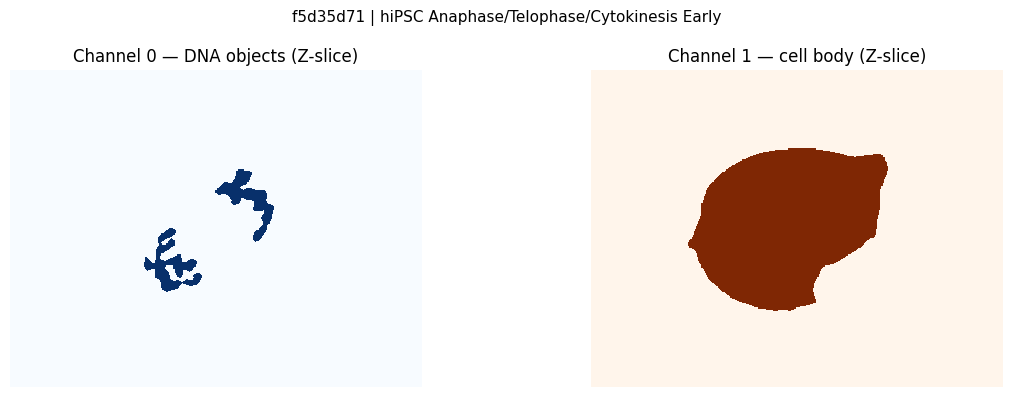

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(dna_mask[mid_z], cmap='Blues', interpolation='nearest')
axes[0].set_title('Channel 0 — DNA objects (Z-slice)')
axes[0].axis('off')
axes[1].imshow(cell_mask[mid_z], cmap='Oranges', interpolation='nearest')
axes[1].set_title('Channel 1 — cell body (Z-slice)')
axes[1].axis('off')
plt.suptitle('f5d35d71 | hiPSC Anaphase/Telophase/Cytokinesis Early', fontsize=11)
plt.tight_layout()
plt.show()


## Case 1 — Whole-cell morphometry

Treat the entire cell body as a **single label**. The returned tensors describe the whole cell as one object.

This is the simplest use case: one binary mask → one set of Minkowski tensors.

In [4]:
label_case1 = cell_mask.astype(int)  # 0 = background, 1 = cell

results_case1 = pk.minkowski_tensors_from_label_image(label_case1, compute="all")
r = results_case1[1]

print('Case 1 — whole cell body')
print(f'  Volume (w000):              {r["w000"] * voxel_size_um**3:.1f} µm³')
print(f'  Surface area (3·w100 = A):  {r["w100"] * voxel_size_um**2 * 3:.1f} µm²')
print(f'  w100 (= A/3):               {r["w100"] * voxel_size_um**2:.1f} µm²')
print(f'  Euler characteristic χ:     {round(3 * r["w300"] / (2 * np.pi))}  (w300 = {r["w300"]:.4f})')
print(f'  Anisotropy (w020_beta):     {r["w020_beta"]:.4f}  (1 = isotropic, 0 = maximally anisotropic)')


Case 1 — whole cell body
  Volume (w000):              3096.6 µm³
  Surface area (3·w100 = A):  1498.3 µm²
  w100 (= A/3):               499.4 µm²
  Euler characteristic χ:     2  (w300 = 4.1888)
  Anisotropy (w020_beta):     0.2773  (1 = isotropic, 0 = maximally anisotropic)


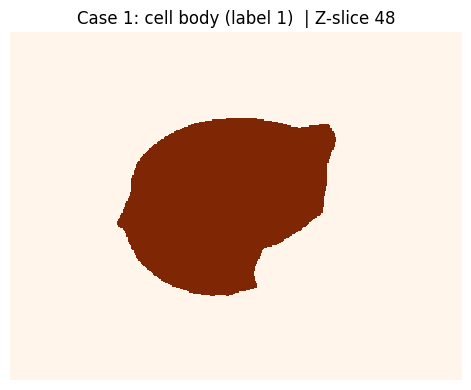

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(label_case1[mid_z], cmap='Oranges', interpolation='nearest', vmin=0, vmax=1)
ax.set_title(f'Case 1: cell body (label 1)  | Z-slice {mid_z}')
ax.axis('off')
plt.tight_layout()
plt.show()

## Case 2 — Two-compartment: DNA objects + whole cell body

Each channel is measured independently with a separate `minkowski_tensors_from_label_image()` call,
so label 2 covers the **full cell body** (not just the cytoplasm).


In [6]:
# Two separate calls — one per channel — so cell body is measured whole
results_case2_dna  = pk.minkowski_tensors_from_label_image(dna_mask.astype(int), compute="all")
results_case2_cell = pk.minkowski_tensors_from_label_image(cell_mask.astype(int), compute="all")

print('Case 2 — two compartments')
for name, res in [('DNA objects (combined)', results_case2_dna), ('whole cell body', results_case2_cell)]:
    r = res[1]
    print(f'  {name}:')
    print(f'    Volume (w000):              {r["w000"] * voxel_size_um**3:.1f} µm³')
    print(f'    Surface area (3·w100 = A):  {r["w100"] * voxel_size_um**2 * 3:.1f} µm²')
    print(f'    Anisotropy (w020_beta):     {r["w020_beta"]:.4f}')


Case 2 — two compartments
  DNA objects (combined):
    Volume (w000):              109.7 µm³
    Surface area (3·w100 = A):  434.9 µm²
    Anisotropy (w020_beta):     0.1179
  whole cell body:
    Volume (w000):              3096.6 µm³
    Surface area (3·w100 = A):  1498.3 µm²
    Anisotropy (w020_beta):     0.2773


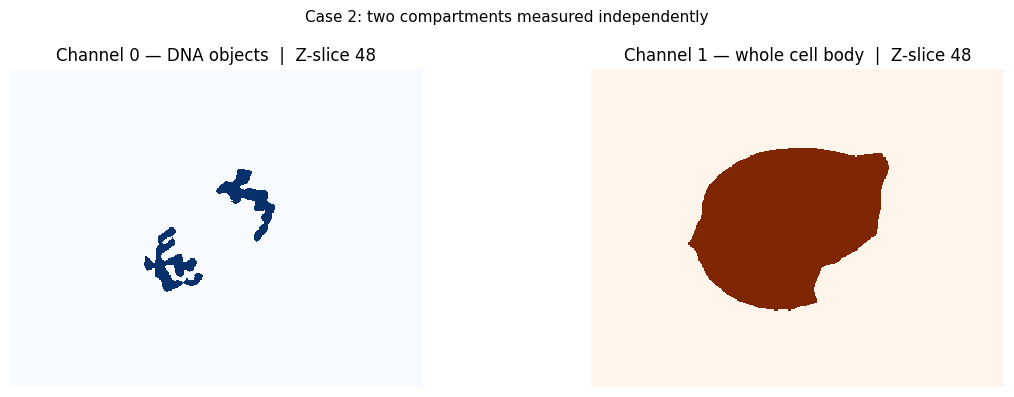

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(dna_mask[mid_z], cmap='Blues', interpolation='nearest')
axes[0].set_title(f'Channel 0 — DNA objects  |  Z-slice {mid_z}')
axes[0].axis('off')
axes[1].imshow(cell_mask[mid_z], cmap='Oranges', interpolation='nearest')
axes[1].set_title(f'Channel 1 — whole cell body  |  Z-slice {mid_z}')
axes[1].axis('off')
plt.suptitle('Case 2: two compartments measured independently', fontsize=11)
plt.tight_layout()
plt.show()


## Case 3 — Per-object: individual DNA object morphometry

The DNA channel contains **3 connected components**.
Using `scipy.ndimage.label` we assign each DNA object a unique label, then compute per-object Minkowski tensors.

DNA objects from dividing cells are expected to be more **elongated** (lower `w020_beta`) than a non-dividing object.


In [8]:
label_case3, n_objects = ndimage.label(dna_mask)
print(f'Found {n_objects} DNA objects')

results_case3 = pk.minkowski_tensors_from_label_image(label_case3, compute="all")

print(f'\n{"Object":<10} {"Volume (µm³)":>14} {"Area (µm²) (3·w100)":>21} {"beta (anisotropy)":>18}')
print('-' * 67)
for label, r in sorted(results_case3.items()):
    print(f'{label:<10} {r["w000"] * voxel_size_um**3:>14.2f} {r["w100"] * voxel_size_um**2 * 3:>21.2f} {r["w020_beta"]:>18.4f}')


Found 3 DNA objects

Object       Volume (µm³)   Area (µm²) (3·w100)  beta (anisotropy)
-------------------------------------------------------------------
1                   55.81                228.12             0.1935
2                   27.10                106.90             0.1439
3                   26.82                 99.85             0.1514


Objects 2 and 3 appear to be part of the same structure segmented as two separate components — their Z ranges (40–72 and 78–110) suggest they occupy different axial regions of what may be a single group of sister chromatids. The table below shows Z coverage per component; adjust `mid_z` in the visualisation above to inspect each one.

| Object | Z range | Span | Voxels |
|--------|---------|------|--------|
| 1 | 38–107 | 70 slices | 44,131 |
| 2 | 40–72 | 33 slices | 21,420 |
| 3 | 78–110 | 33 slices | 21,195 |

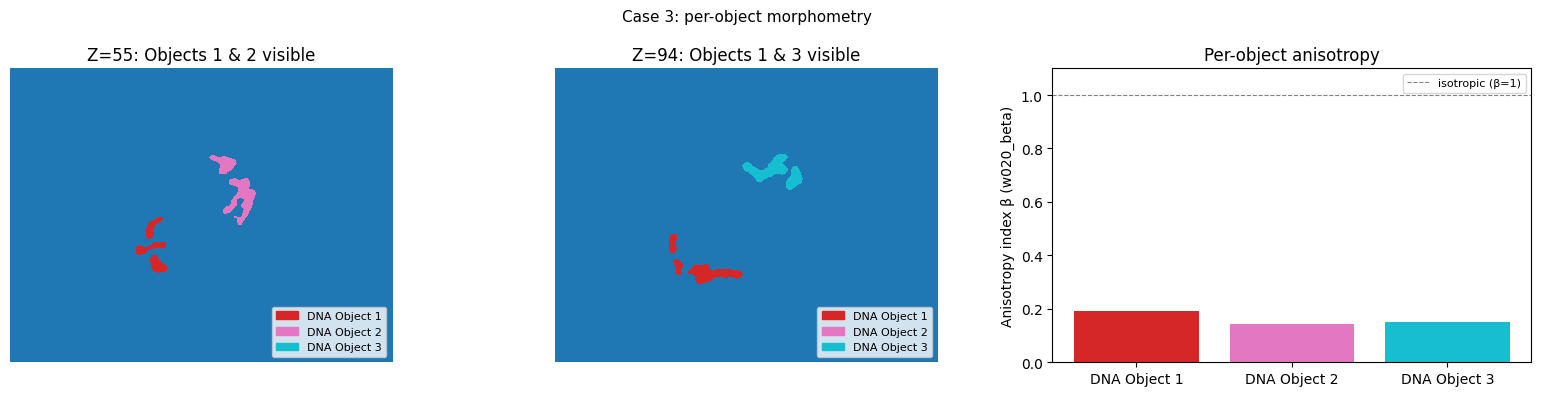

In [9]:
cmap3 = plt.colormaps['tab10'].resampled(n_objects + 1)

# Objects 1, 2 and 3 do not all occupy the same Z-range (see table above).
# Two slices are shown: one where Objects 1 & 2 are visible (Z=55),
# and one where Objects 1 & 3 are visible (Z=94).
z_obj12 = 55   # mid-Z of Object 2 (range 40-72); Object 1 also present
z_obj13 = 94   # mid-Z of Object 3 (range 78-110); Object 1 also present

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(label_case3[z_obj12], cmap=cmap3, vmin=0, vmax=n_objects, interpolation='nearest')
axes[0].set_title(f'Z={z_obj12}: Objects 1 & 2 visible')
axes[0].axis('off')

axes[1].imshow(label_case3[z_obj13], cmap=cmap3, vmin=0, vmax=n_objects, interpolation='nearest')
axes[1].set_title(f'Z={z_obj13}: Objects 1 & 3 visible')
axes[1].axis('off')

patches3 = [mpatches.Patch(color=cmap3(i), label=f'DNA Object {i}') for i in range(1, n_objects + 1)]
for ax in axes[:2]:
    ax.legend(handles=patches3, loc='lower right', fontsize=8)

# Anisotropy bar chart
labels_bar = [f'DNA Object {i}' for i in sorted(results_case3)]
betas      = [results_case3[i]['w020_beta'] for i in sorted(results_case3)]
colors     = [cmap3(i) for i in sorted(results_case3)]
axes[2].bar(labels_bar, betas, color=colors)
axes[2].axhline(1.0, color='grey', linestyle='--', linewidth=0.8, label='isotropic (β=1)')
axes[2].set_ylabel('Anisotropy index β (w020_beta)')
axes[2].set_ylim(0, 1.1)
axes[2].set_title('Per-object anisotropy')
axes[2].legend(fontsize=8)

plt.suptitle('Case 3: per-object morphometry', fontsize=11)
plt.tight_layout()
plt.show()


## Case 3 — Alternative: `autolabel=True` (built-in connected-component detection)

`minkowski_tensors_from_label_image` can also detect connected components **internally** without a prior call to `scipy.ndimage.label`.
When `autolabel=True`, the function ignores label values, treats the image as binary, builds a single mesh from all non-zero voxels, and runs connected-component detection on the resulting triangulation — equivalent to `minkowski_tensors(..., labels='auto')`.

This is a one-call alternative to the two-step `ndimage.label` → `minkowski_tensors_from_label_image` pattern used in Case 3.
The per-object tensors should be identical; the only difference is key naming: results are keyed by **0-based component index** instead of the label values assigned by `ndimage.label`.

> **Note on indexing:** `autolabel=True` keys components by detection order on the mesh (0-based), which may differ from the `ndimage.label` order (1-based). The comparison below aligns objects by volume.


In [10]:
# autolabel=True: pykarambola detects components internally — no scipy.ndimage.label needed
results_case3_auto = pk.minkowski_tensors_from_label_image(
    dna_mask.astype(int), autolabel=True, compute="all"
)

print(f'autolabel=True  → {len(results_case3_auto)} objects, keys: {sorted(results_case3_auto)}')
print(f'ndimage.label   → {len(results_case3)} objects,  keys: {sorted(results_case3)}')

# Align objects by descending volume (largest first) to compare regardless of key ordering
def sorted_by_volume(results):
    return sorted(results.values(), key=lambda r: r['w000'], reverse=True)

case3_sorted = sorted_by_volume(results_case3)
auto_sorted  = sorted_by_volume(results_case3_auto)

print(f'\n{"Rank":<6} {"ndimage vol (µm³)":>19} {"autolabel vol (µm³)":>21} '
      f'{"Δvol":>10} {"ndimage β":>11} {"autolabel β":>13} {"Δβ":>8}')
print('-' * 92)
for i, (r3, ra) in enumerate(zip(case3_sorted, auto_sorted)):
    vol3  = r3['w000'] * voxel_size_um**3
    vola  = ra['w000'] * voxel_size_um**3
    beta3 = r3['w020_beta']
    betaa = ra['w020_beta']
    print(f'{i+1:<6} {vol3:>19.4f} {vola:>21.4f} {vol3-vola:>10.2e} '
          f'{beta3:>11.4f} {betaa:>13.4f} {beta3-betaa:>8.2e}')

vol_match  = all(abs(r3['w000']      - ra['w000'])      < 1e-8 for r3, ra in zip(case3_sorted, auto_sorted))
beta_match = all(abs(r3['w020_beta'] - ra['w020_beta']) < 1e-8 for r3, ra in zip(case3_sorted, auto_sorted))
print(f'\nAll volumes match:  {vol_match}')
print(f'All β match:        {beta_match}')


autolabel=True  → 3 objects, keys: [1, 2, 3]
ndimage.label   → 3 objects,  keys: [1, 2, 3]

Rank     ndimage vol (µm³)   autolabel vol (µm³)       Δvol   ndimage β   autolabel β       Δβ
--------------------------------------------------------------------------------------------
1                  55.8136               55.8136   0.00e+00      0.1935        0.1935 0.00e+00
2                  27.0975               27.0975   0.00e+00      0.1439        0.1439 0.00e+00
3                  26.8205               26.8205   0.00e+00      0.1514        0.1514 0.00e+00

All volumes match:  True
All β match:        True


## Case 3b — Merging segmented components: Minkowski tensor additivity

If objects 2 and 3 belong to the same structure, we can merge them into a single label and recompute.

Minkowski tensors have a key additivity property for **disjoint** objects:

| Quantity | Additive? | Notes |
|----------|-----------|-------|
| `w000`, `w100`, `w200`, `w300` | ✅ yes | Scalar functionals sum directly |
| `w020` … `w202` (tensor matrices) | ✅ yes | W_merged = W_2 + W_3 |
| `_trace` | ✅ yes | Trace is linear |
| `_eigvals`, `_eigvecs` | ❌ no | Eigensystem of sum ≠ sum of eigensystems |
| `_beta` (anisotropy index) | ❌ no | Must recompute from merged tensor |
| `_trace_ratio` | ❌ no | Ratio — must recompute |

The correct approach is to **re-label** and re-run rather than combine derived quantities.

In [11]:
# Merge objects 2 and 3 into a single label
label_merged = label_case3.copy()
label_merged[label_case3 == 3] = 2  # relabel object 3 → 2

# Use center=None so all objects share the same reference frame —
# required for tensor matrix additivity (per-centroid centering shifts
# each object to its own origin, making position-dependent tensors
# non-comparable across objects)
kw = dict(compute="all", center=None)
results_ind = pk.minkowski_tensors_from_label_image(label_case3, **kw)
results_mrg = pk.minkowski_tensors_from_label_image(label_merged, **kw)

r2, r3, rm = results_ind[2], results_ind[3], results_mrg[2]

vs2 = voxel_size_um**2
vs3 = voxel_size_um**3

print("Additivity check (objects 2 + 3 merged), center=None:")
print(f"  w000 (volume): {r2['w000']*vs3:.2f} + {r3['w000']*vs3:.2f} = {(r2['w000']+r3['w000'])*vs3:.2f} µm³  |  merged: {rm['w000']*vs3:.2f} µm³")
print(f"  w100 (area):   {r2['w100']*vs2:.2f} + {r3['w100']*vs2:.2f} = {(r2['w100']+r3['w100'])*vs2:.2f} µm²  |  merged: {rm['w100']*vs2:.2f} µm²")
print(f"  w300 (Euler):  {r2['w300']:.4f} + {r3['w300']:.4f} = {r2['w300']+r3['w300']:.4f}  |  merged: {rm['w300']:.4f}")
print(f"  w102 matrix:   max|W2+W3 - W_merged| = {abs(r2['w102']+r3['w102']-rm['w102']).max():.2e}  (~0 = additive)")
print()
print("Non-additive — must recompute from merged tensor:")
print(f"  w102_beta obj2:   {r2['w102_beta']:.4f}")
print(f"  w102_beta obj3:   {r3['w102_beta']:.4f}")
print(f"  sum:              {r2['w102_beta']+r3['w102_beta']:.4f}")
print(f"  w102_beta merged: {rm['w102_beta']:.4f}  <-- differs from sum")

Additivity check (objects 2 + 3 merged), center=None:
  w000 (volume): 27.10 + 26.82 = 53.92 µm³  |  merged: 53.92 µm³
  w100 (area):   35.63 + 33.28 = 68.92 µm²  |  merged: 68.92 µm²
  w300 (Euler):  4.1888 + 4.1888 = 8.3776  |  merged: 8.3776
  w102 matrix:   max|W2+W3 - W_merged| = 4.55e-13  (~0 = additive)

Non-additive — must recompute from merged tensor:
  w102_beta obj2:   0.7912
  w102_beta obj3:   0.7680
  sum:              1.5592
  w102_beta merged: 0.8633  <-- differs from sum


## Summary

The same binary segmentation yields fundamentally different measurements depending on how labels are assigned:

| Case | Input to function | Key argument | Output |
|------|-------------------|--------------|--------|
| 1 | `cell_mask.astype(int)` — single label | `autolabel=False` (default) | 1 result — whole cell |
| 2 | `dna_mask.astype(int)` or `cell_mask.astype(int)` — one call per channel | `autolabel=False` (default) | 1 result per call (whole compartment) |
| 3 | `ndimage.label(dna_mask)` — pre-labeled integer image | `autolabel=False` (default) | N results — per DNA object |
| 3 (alt) | `dna_mask.astype(int)` — raw binary mask | `autolabel=True` | N results — per DNA object (identical to Case 3) |

Key observations:
- **Case 1 vs Case 3**: same DNA binary mask, but Case 1 (`autolabel=False`, single label value) treats all DNA objects as one body while Case 3 resolves each individually.
- **`autolabel=False` (default)**: the function trusts the label values you provide. A binary mask has one nonzero label → one result. A pre-labeled integer image has N labels → N results.
- **`autolabel=True`**: the function ignores label values and detects connected components on the mesh internally — no preprocessing with `scipy.ndimage.label` required. Results are identical to Case 3.
- **Case 2**: per-compartment comparison shows DNA objects and the whole cell body have different anisotropy signatures. Using separate calls ensures the cell body measurement is not truncated to cytoplasm.


---

## Figure 21 — 3D mesh render: single-label vs per-object

Both panels use the **DNA channel** to make the conceptual distinction direct:

- **Case (i)** — entire DNA channel as one label. All three DNA blobs are treated as a single object; one set of Minkowski tensors describes the aggregate structure.
- **Case (ii)** — each DNA blob gets its own label via `scipy.ndimage.label`. Three separate meshes, three independent tensor sets.

Each figure is rendered at 6 different viewing angles so you can pick the most informative one.
Outputs saved to `assets/figure21_case_i_angles.svg` and `assets/figure21_case_ii_angles.svg`.

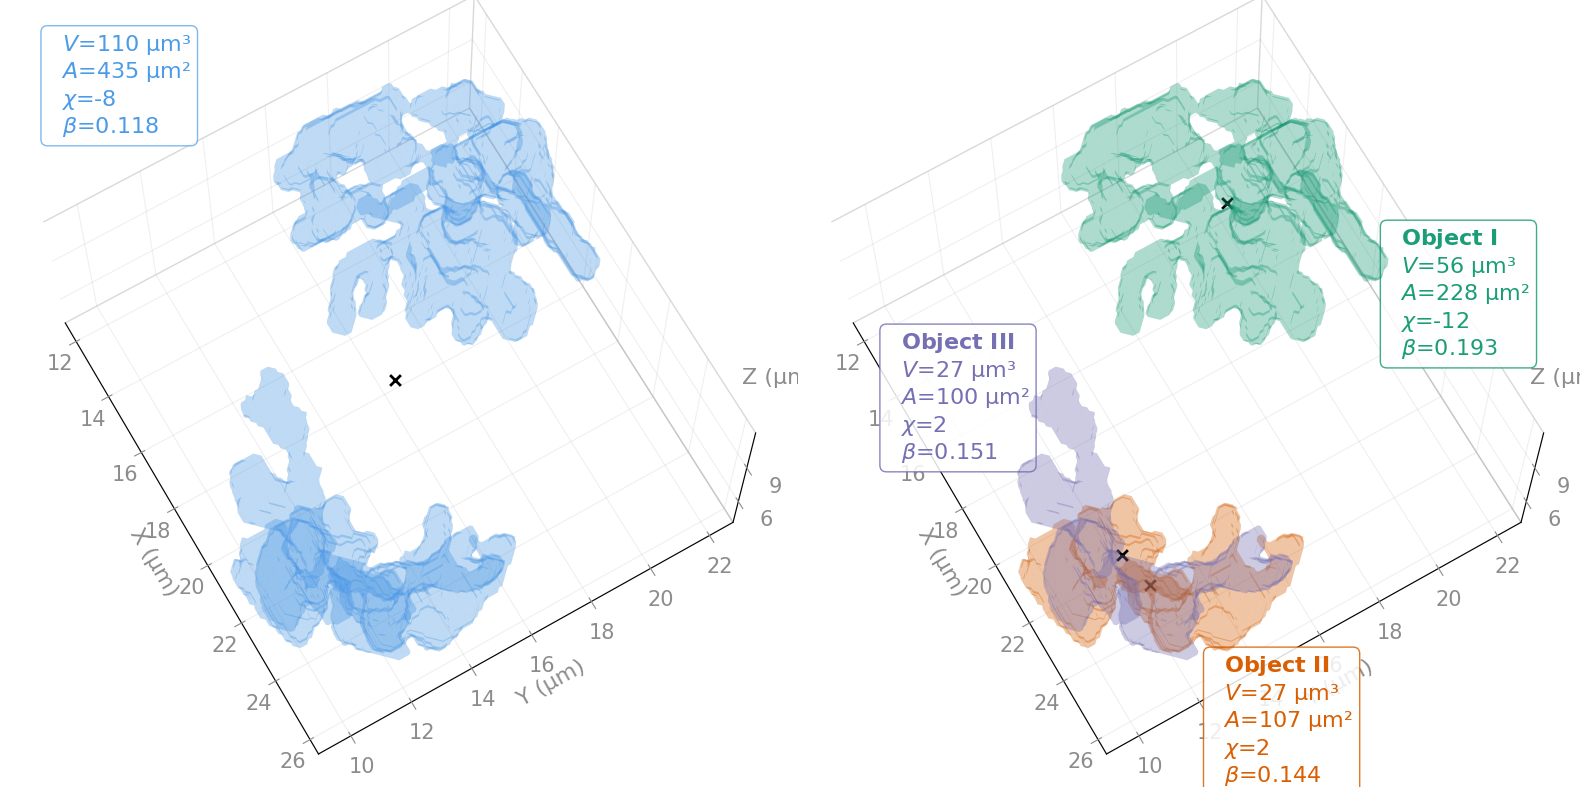

Saved → assets/figure21.pdf


In [21]:
BASE_FONT = 16
plt.rcParams.update({'font.size': BASE_FONT, 'axes.titlesize': BASE_FONT+2, 'axes.labelsize': BASE_FONT, 'xtick.labelsize': BASE_FONT-1, 'ytick.labelsize': BASE_FONT-1})

SPACING = (voxel_size_um,) * 3
dark2   = plt.colormaps['Dark2']
ROMAN = {1: 'I', 2: 'II', 3: 'III'}

# ── helpers ───────────────────────────────────────────────────────────────────
def style_ax(ax):
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis.pane.set_edgecolor((0.7, 0.7, 0.7, 0.25))
        axis._axinfo['grid']['color'] = (0.7, 0.7, 0.7, 0.2)
        axis.label.set_color((0.55, 0.55, 0.55))
    ax.tick_params(colors=(0.55, 0.55, 0.55))
    ax.zaxis.set_major_locator(plt.MaxNLocator(nbins=3, integer=False))
    ax.set_xlabel('X (µm)'); ax.set_ylabel('Y (µm)'); ax.set_zlabel('')
    ax.view_init(elev=70, azim=-30)

def fit_ax(ax, verts):
    lo, hi = verts.min(0), verts.max(0)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect((hi - lo).tolist())
    ax.text(hi[0]-1, hi[1], hi[2]+2, 'Z (µm)',
            color=(0.55,0.55,0.55), ha='left', va='center')

def mesh_xyz(mask):
    v, f, _, _ = measure.marching_cubes(mask.astype(np.float32), level=0.5, spacing=SPACING)
    return v[:, [2, 1, 0]], f                                     # ZYX → XYZ

def centroid_xyz(mask):
    czyx = ndimage.center_of_mass(mask)
    return np.array([czyx[2], czyx[1], czyx[0]]) * voxel_size_um # XYZ µm

def fmt_stats(r, lbl=None):
    prefix = f'  $\\mathbf{{Object\\ {ROMAN[lbl]}}}$\n' if lbl else ''
    return (f'{prefix}'
            f'  $V$={r["w000"] * voxel_size_um**3:.0f} µm³\n'
            f'  $A$={r["w100"] * 3 * voxel_size_um**2:.0f} µm²\n'
            f'  $\\chi$={round(r["w300"] * 3 / (2 * np.pi))}\n'
            f'  $\\beta$={r["w020_beta"]:.3f}')

# ── pre-compute ───────────────────────────────────────────────────────────────
verts_i, faces_i = mesh_xyz(dna_mask)
center_i         = centroid_xyz(dna_mask)

TEXT_OFFSETS = {1: [6.5,1.5,0], 2: [6,-1.5,0], 3: [-5,-4.5,1.5]}

obj_data = {}
for lbl in range(1, n_objects + 1):
    mask = label_case3 == lbl
    verts, faces = mesh_xyz(mask)
    color = dark2(lbl - 1)
    obj_data[lbl] = dict(verts=verts, faces=faces, color=color,
                         center=centroid_xyz(mask),
                         stats=fmt_stats(results_case3[lbl], lbl=lbl))

all_v = np.vstack([d['verts'] for d in obj_data.values()])

# ── figure ────────────────────────────────────────────────────────────────────
fig, (ax_i, ax_ii) = plt.subplots(1, 2, figsize=(16, 8),
                                   subplot_kw={'projection': '3d'})

# (a) single label
ax_i.add_collection3d(Poly3DCollection(verts_i[faces_i], alpha=0.2,
                                        facecolor='#4C9BE8', edgecolor='none'))
fit_ax(ax_i, verts_i); style_ax(ax_i)
# ax_i.set_title('(a)  entire DNA channel as one label\n(1 set of Minkowski tensors)')
ax_i.text2D(0.05, 0.97, fmt_stats(results_case2_dna[1]),
            transform=ax_i.transAxes, va='top', color='#4C9BE8',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='#4C9BE8'))
ax_i.scatter(*center_i, marker='x', s=60, color='black', linewidths=2, depthshade=False)

# (b) per-object
for lbl, d in obj_data.items():
    c = d['color']
    ax_ii.add_collection3d(Poly3DCollection(d['verts'][d['faces']],
                                             alpha=0.2, facecolor=c, edgecolor='none'))
    cx, cy, cz = d['center']
    off = TEXT_OFFSETS[lbl]
    ax_ii.text(cx+off[0], cy+off[1], cz+off[2], d['stats'],
               color=c, va='bottom',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.85,
                         edgecolor=c, linewidth=1.0))
    ax_ii.scatter([cx], [cy], [cz], marker='x', s=60, color='black',
                  linewidths=2, depthshade=False)

fit_ax(ax_ii, all_v); style_ax(ax_ii)
# ax_ii.set_title('(b)  per-object DNA morphometry\n(3 labels → 3 independent tensor sets)')

# plt.suptitle('Single-label vs per-object', fontsize=BASE_FONT+3)
plt.tight_layout()
plt.savefig('../assets/figure21.pdf', bbox_inches='tight', dpi=150)
plt.savefig('../assets/figure21.svg', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → assets/figure21.pdf')
